# Task 1: Data Loading and Initial Inspection
1. Load the dataset (e.g., using pandas in Python).

2. Display the first 5 rows to get a quick look at the data structure.

3. Check the data types of all columns (.info()).

4. Get descriptive statistics of the numerical columns (.describe()).

5. Identify the total number of missing values for each column.



## Import framework

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Mounting drive to colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Load the dataset (e.g., using pandas in Python).

In [ ]:
url = "/content/drive/MyDrive/AI ML Engineering Bootcamp/titanic.csv"
titanic_df = pd.read_csv(url)

### 2. Display the first 5 rows to get a quick look at the data structure.

In [ ]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Check the data types of all columns (.info()).


In [ ]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 4. Get descriptive statistics of the numerical columns (.describe()).

In [ ]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 5. Identify the total number of missing values for each column.

In [ ]:
titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Task 2: Handling Missing Values
Missing data can skew analysis. For this task, you will address the missing values in three key columns: Age, Cabin, and Embarked.

**Cabin:**

Calculate the percentage of missing values in the Cabin column.

**Decision:** Do we need to drop the Cabin column entirely from the analysis? Briefly justify your reason.


**Embarked:**

Find the most frequent port of embarkation (the mode).Impute the missing values in the Embarked column with the mode.

**Age**

Impute the missing values in the Age column with the median age.



---


**Cabin:**

Calculate the percentage of missing values in the Cabin column.

**Decision:** Do we need to drop the Cabin column entirely from the analysis? Briefly justify your reason.

In [ ]:
missing_value_for_age_cabin_embarked = titanic_df[["Age", "Cabin", "Embarked"]].isnull().sum()

print("mssing values for Age, Cabin, and Embarked columns:")
print("-"*50)
print(missing_value_for_age_cabin_embarked)


print("-"*50)

missing_cabin = titanic_df["Cabin"].isnull().sum()
percentage_of_missong_cabin = (missing_cabin/len(titanic_df))*100
print(f"The percentage of missing values in the Cabin column is {percentage_of_missong_cabin:.2f}%")

mssing values for Age, Cabin, and Embarked columns:
--------------------------------------------------
Age         177
Cabin       687
Embarked      2
dtype: int64
--------------------------------------------------
The percentage of missing values in the Cabin column is 77.10%


**The Cabin column contains approximately 77% missing values, which is a very high proportion. Imputing such a large amount of missing data would not be reliable and could introduce bias into the analysis. Therefore, it is appropriate to drop the Cabin column from the dataset.**



---


**Embarked:**

Find the most frequent port of embarkation (the mode).Impute the missing values in the Embarked column with the mode.



In [ ]:
most_frequest_port = titanic_df["Embarked"].mode()[0]
print(f"The most frequent port of embarkation is {most_frequest_port}")
print("-"*50)


titanic_df["Embarked"].fillna(most_frequest_port, inplace = True)

missing_value_for_embarked = titanic_df["Embarked"].isnull().sum()
print(f"After imputing the missing value for Embarked is {missing_value_for_embarked}")


The most frequent port of embarkation is S
--------------------------------------------------
After imputing the missing value for Embarked is 0


/tmp/ipykernel_429/1570383811.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df["Embarked"].fillna(most_frequest_port, inplace = True)




---


**Age**

Impute the missing values in the Age column with the median age.

In [ ]:
median_of_age = titanic_df["Age"].median()
print("Median of Age Column : ",median_of_age)
print("="*50)

titanic_df["Age"].fillna(median_of_age, inplace = True)
missig_value_of_age = titanic_df["Age"].isnull().sum()

print(f"After Imputing the number of missing value of Age column is {missig_value_of_age}")

Median of Age Column :  28.0
After Imputing the number of missing value of Age column is 0


/tmp/ipykernel_429/2732517588.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df["Age"].fillna(median_of_age, inplace = True)


# Task 3: Univariate Analysis
Univariate analysis looks at a single variable at a time.

**Survival Rate:**

- Calculate the overall survival rate (percentage of passengers who survived).

- Visualize the distribution of the Survived variable (e.g., a count plot/bar chart).

**Passenger Class (Pclass):**

- Visualize the distribution of Pclass using a count plot.

- Identify which class had the most passengers.



**Age Distribution:**

- Plot a histogram of the Age column to visualize its distribution.



---

**Survival Rate:**

- Calculate the overall survival rate (percentage of passengers who survived).

- Visualize the distribution of the Survived variable (e.g., a count plot/bar chart).


Total Number of passenger : 891
Number of survival :  342
Number of Not survival :  549
Over all survival rate is 38.38%


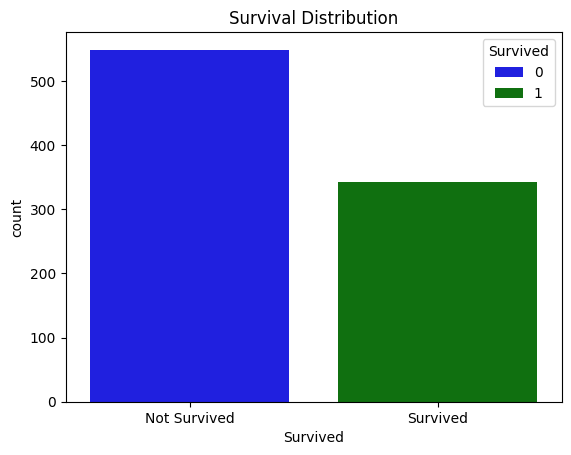

In [ ]:
titanic_df.head()
number_of_survival = len(titanic_df[titanic_df["Survived"]==1])
total_number_of_passenger = len(titanic_df)
print(f"Total Number of passenger : {total_number_of_passenger}")
print("Number of survival : ",number_of_survival)
print("Number of Not survival : ",total_number_of_passenger - number_of_survival)

survival_rate = (number_of_survival/total_number_of_passenger)* 100

print("="*50)

print(f"Over all survival rate is {survival_rate:.2f}%")
print("="*50)


sns.countplot(x='Survived', hue='Survived', data=titanic_df, palette=["blue", "green"])
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.title("Survival Distribution")
plt.show()



---


**Passenger Class (Pclass):**

- Visualize the distribution of Pclass using a count plot.

- Identify which class had the most passengers.

/tmp/ipykernel_429/3694104795.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Pclass", data=titanic_df, palette=["teal", "crimson", "navy"])


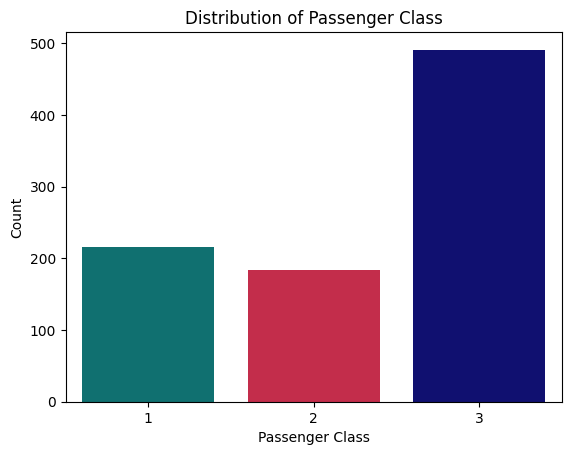

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Most passengers were in Class 3 (491 passengers).


In [ ]:
sns.countplot(x="Pclass", data=titanic_df, palette=["teal", "crimson", "navy"])
plt.title("Distribution of Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

passenger_of_each_class = titanic_df["Pclass"].value_counts()

print("="*50)
print(passenger_of_each_class)
print("="*50)
print(f"\nMost passengers were in Class {passenger_of_each_class.idxmax()} ({passenger_of_each_class.max()} passengers).")



---


**Age Distribution:**

- Plot a histogram of the Age column to visualize its distribution.

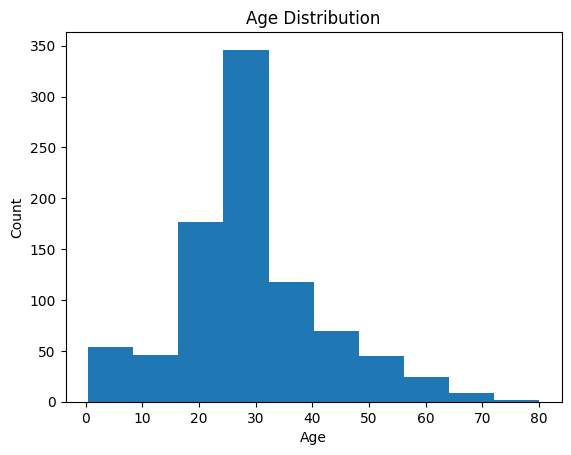

In [ ]:
plt.hist(titanic_df['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()



# Task 4: Bivariate and Multivariate Analysis
Bivariate analysis explores the relationship between two variables, specifically focusing on how other features relate to the target variable (Survived).



**Survival by Sex:**

- Create a crosstabulation (or a grouped count) to show the count of survivors and non-survivors grouped by Sex.

- Visualize this relationship using a stacked bar chart or a grouped count plot.

- **Question:** Which gender had a significantly higher survival rate?



**Survival by Class (Pclass):**

- Calculate and visualize the survival rate for each Pclass.

- **Question:** Is there a clear correlation between ticket class and survival probability?



**Survival by Age:**

- Plot and compare the age distribution of survivors vs. non-survivors.

- Observation: What does the plot suggest about the survival chances of children and the elderly?



**Survival by Port of Embarkation (Embarked):**

- Calculate and visualize the survival rate for each Embarked port.



---
**Survival by Sex:**

- Create a crosstabulation (or a grouped count) to show the count of survivors and non-survivors grouped by Sex.

- Visualize this relationship using a stacked bar chart or a grouped count plot.

- **Question:** Which gender had a significantly higher survival rate?


      Sex  Survived  count
0  female         1    233
1  female         0     81
2    male         0    468
3    male         1    109


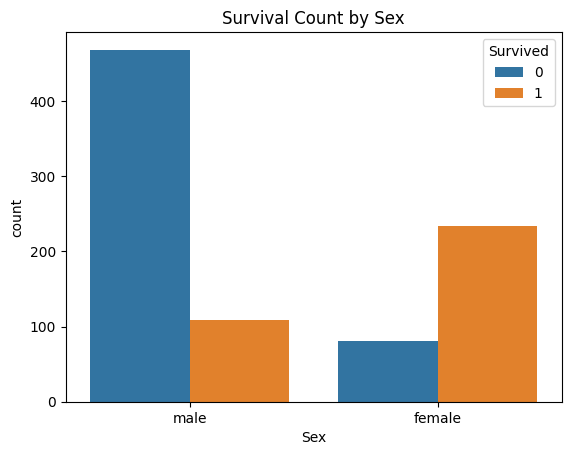

--------------------------------------------------
Survival rate for female is 74.20%
Survival rate for male is 18.89%
--------------------------------------------------
So, Female had more chance to survive


In [70]:
survival_by_sex = titanic_df[["Sex", "Survived"]].groupby("Sex", as_index=False).value_counts()

print(survival_by_sex)

print("="*50)


sns.countplot(x='Sex', hue='Survived', data=titanic_df)
plt.title('Survival Count by Sex')
plt.show()

survival_rate = titanic_df.groupby("Sex")["Survived"].mean()*100
print("-"*50)

print(f"Survival rate for female is {survival_rate.loc['female']:.2f}%")
print(f"Survival rate for male is {survival_rate.loc['male']:.2f}%")
print("-"*50)
print("So, Female had more chance to survive")




---


**Survival by Class (Pclass):**

- Calculate and visualize the survival rate for each Pclass.

- **Question:** Is there a clear correlation between passenger class and survival probability?

Survival_rate_by_Pclass : 
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


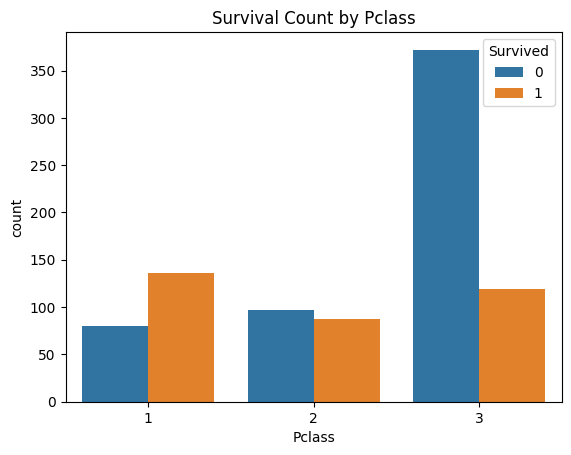

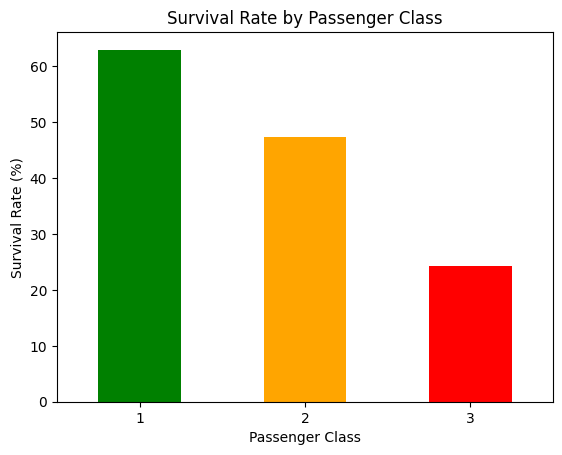

In [79]:
survival_rate_by_Pclass = titanic_df.groupby("Pclass")["Survived"].mean()*100
print(f"Survival_rate_by_Pclass : \n{survival_rate_by_Pclass}")

print("="*50)
sns.countplot(x='Pclass', hue='Survived', data=titanic_df)
plt.title('Survival Count by Pclass')
plt.show()

print("="*50)

survival_rate_by_Pclass.plot(
    kind="bar",
    color=["green", "orange", "red"]
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()



**Yes. There is a clear correlation between passenger class and survival. First-class passengers had the highest survival rate, while third-class passengers had the lowest.**



---
**Survival by Age:**

- Plot and compare the age distribution of survivors vs. non-survivors.

- Observation: What does the plot suggest about the survival chances of children and the elderly?



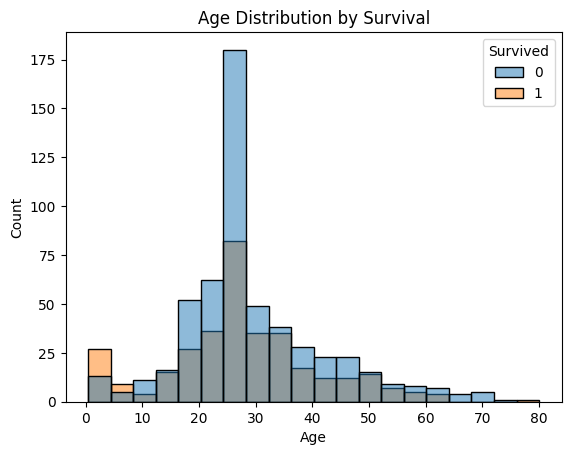

In [86]:
sns.histplot(
    data=titanic_df,
    x="Age",
    hue="Survived",
    bins=20,
    multiple="layer"
)

plt.title("Age Distribution by Survival")
plt.show()

**The plot generally suggests that children had better survival chances, while elderly passengers tended to have lower survival rates compared with younger adults.**



---

**Survival by Port of Embarkation (Embarked):**

- Calculate and visualize the survival rate for each Embarked port.

Survival rate by port of Embarked
--------------------------------------------------
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


Text(0, 0.5, 'Survival Rate (%)')

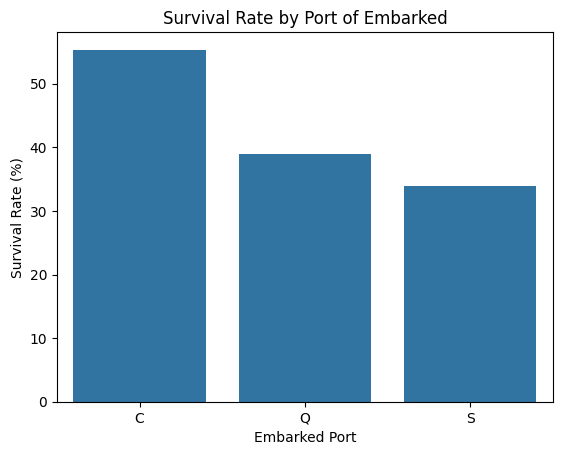

In [92]:
embarked_survival_rate = titanic_df.groupby("Embarked")["Survived"].mean() * 100

print("Survival rate by port of Embarked")
print("-"*50)
print(embarked_survival_rate)

print("="*50)

sns.barplot(x=embarked_survival_rate.index, y=embarked_survival_rate.values)
plt.title("Survival Rate by Port of Embarked")
plt.xlabel("Embarked Port")
plt.ylabel("Survival Rate (%)")




---


# Task 5: Conclusion and Insights
Based on your EDA, write a brief (3-5 sentences) conclusion summarizing the most significant factors affecting survival on the Titanic. Highlight the top 2-3 features that appear to be the strongest predictors of survival.



- **EDA** indicate that **SEX** was the strongest predictor of survival.
with female passengers having a significant chance to survive than male.
- **Passenger class** also had a major impact on survival.
as first class passenger were more likely to survive than those in second and third class.
- The analysis of **Age** class suggest that children had better survival chance while older were less.
## Overall top three factors that most effect on survival on the titanic were:
1. Sex
2. Passenger Class
3. Age